**Why this notebook auto-reloads code**

The next cell enables IPython's `autoreload` so changes you make in the `netsci` module are picked up automatically before each cell runs, without restarting the kernel.

Reference: https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [1]:
# Auto-reload netsci modules if code changes
%load_ext autoreload
%autoreload 2

# Week 5: Community Detection

**Learning objectives** — After this lab you should be able to:

- Explain what a community is in a network (dense within, sparse between)
- Motivate community detection with real-world applications
- Compute and interpret **modularity** as a partition quality score
- Write out the modularity formula and explain each term
- Apply the **Louvain** algorithm (bottom-up) and the **Girvan-Newman** algorithm (top-down)
- Contrast bottom-up vs top-down approaches and articulate when each is preferable
- Evaluate detected communities against ground truth using **NMI**
- Use the **resolution parameter** to control community granularity
- Visualize communities with both static and interactive tools

People naturally form groups — friend circles, departments, clubs.
In network science, these groups are called **communities**: subsets of nodes that are
densely connected to each other but sparsely connected to the rest of the network.

This week we learn how to **find** communities automatically and **evaluate** how good
the detected groups are. Community detection sits at the intersection of graph
theory, machine learning, and applied statistics — it is arguably the most practically
useful technique in the network science toolbox.

**Why does community detection matter?** It is one of the most widely applied techniques in network science:
- **Social media**: identifying echo chambers, coordinated inauthentic behavior, and interest groups for content recommendation. Facebook's 2020 integrity report used community detection to map networks of fake accounts.
- **Biology**: discovering protein complexes and functional modules in protein interaction networks. The human interactome (~20,000 proteins) contains hundreds of functional communities.
- **Fraud detection**: finding rings of accounts that transact suspiciously among themselves but rarely with outsiders. A fraud ring of 50 accounts in a network of millions appears as a tiny, dense subgraph.
- **Epidemiology**: tracing contact clusters during disease outbreaks — we'll connect this directly in Week 6.
- **Neuroscience**: mapping functional brain regions from fMRI connectivity data.

In each case, the core question is the same: *which groups of nodes are more tightly
connected internally than expected by chance?* The phrase "expected by chance" is
critical — it's what separates community detection from simple clustering. We need a
baseline to decide whether the density we observe is meaningful or just a consequence
of the degree sequence. We'll formalize this idea in Section 3.

In [2]:
import networkx as nx
import numpy as np
from collections import defaultdict
from networkx.algorithms.community import girvan_newman
from sklearn.metrics import normalized_mutual_info_score
from netsci.loaders import load_graph
from netsci.utils import SEED, graph_summary, partition_to_labels
from netsci import viz

---
## 1. Datasets

We use three networks this week:
- **Karate Club** — ground truth factions known
- **College Football** — teams grouped by conference
- **Game of Thrones** — character interactions

This week's three networks each offer a different perspective on community detection:

- **Zachary's Karate Club** (34 nodes, 78 edges) — the "hello world" of community
  detection. Wayne Zachary observed this club in 1977 and documented the real split into
  two factions after a dispute between the instructor (node 0) and the club president
  (node 33), giving us **ground truth** to validate algorithms against. Nearly every
  community detection paper benchmarks on this network.
- **College Football** (115 nodes, 613 edges) — NCAA Division I-A teams connected by
  games played during a season. The natural communities are **conferences** (SEC, Big
  Ten, Pac-10, etc.), providing another ground-truth benchmark. This network is larger
  and has more communities (~12) than Karate Club, testing whether algorithms scale
  beyond a simple 2-way split.
- **Game of Thrones** (796 nodes) — character interactions from the books. There is
  **no ground truth** — we must discover communities and interpret them narratively.
  This is the more realistic scenario: in most real-world applications, you don't know
  the "right" answer and must evaluate results qualitatively.

This progression — known ground truth → known ground truth (harder) → no ground truth —
mirrors how you'll use community detection in practice: validate on benchmarks, then
apply with confidence to new data.

In [3]:
G_karate = load_graph("karate")
graph_summary(G_karate)
print()
G_football = load_graph("football")
graph_summary(G_football)
print()
G_got = load_graph("got")
graph_summary(G_got)

karate: 34 nodes, 78 edges (undirected)
Graph Summary: Zachary's Karate Club
  Type:        undirected
  Nodes:       34
  Edges:       78
  Density:     0.1390
  Avg degree:  4.59
  Components:  1
  Avg clustering: 0.5706

football: 115 nodes, 613 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       115
  Edges:       613
  Density:     0.0935
  Avg degree:  10.66
  Components:  1
  Avg clustering: 0.4032

got: 796 nodes, 2823 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       796
  Edges:       2823
  Density:     0.0089
  Avg degree:  7.09
  Components:  1
  Avg clustering: 0.4859


**Reading the output**: Note the density of each network. The Karate Club is relatively
dense for its size — most members interact with many others, which is typical of small
social groups. The Football network has a higher average degree because each team plays
~10-12 games per season. The GoT network is much sparser — most characters interact
with only a handful of others, with a few protagonists (Tyrion, Jon, Daenerys) acting
as high-degree hubs connecting different storylines.

---
## 2. What are Communities?

Before we build algorithms, let's develop intuition about what communities *look like*
in a graph. The Karate Club is ideal for this because we already know the ground-truth
split — the club divided into two factions after a dispute between the instructor
(Mr. Hi, node 0) and the president (Officer, node 33).

The first plot below shows a toy example: two clear communities (cliques) connected by
a single bridge edge. The second plot shows the real Karate Club colored by faction.
Look for the same pattern — dense internal connections, sparse bridges.

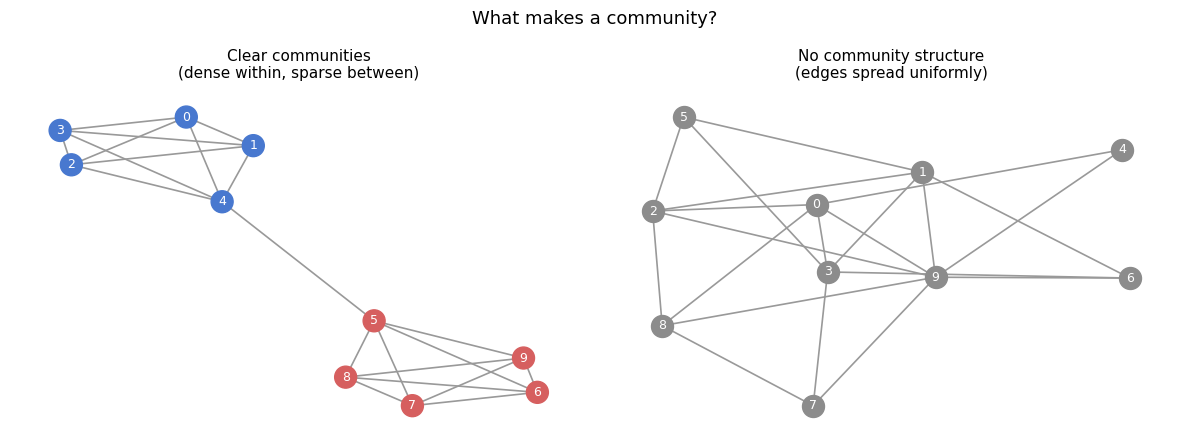

In [4]:
viz.plot_community_concept()

**Reading the figure**: The left panel is an idealized case — two 5-node cliques
(complete subgraphs) joined by exactly one edge. Every node has 4 internal connections
and at most 1 external one, making the community boundary unambiguous. The right panel
shows what happens when edges are spread uniformly at random: no region is denser than
any other, so there are no meaningful communities to find. Real networks fall between
these extremes — communities exist but their boundaries are fuzzy, which is why we need
algorithms and quality metrics rather than visual inspection alone.

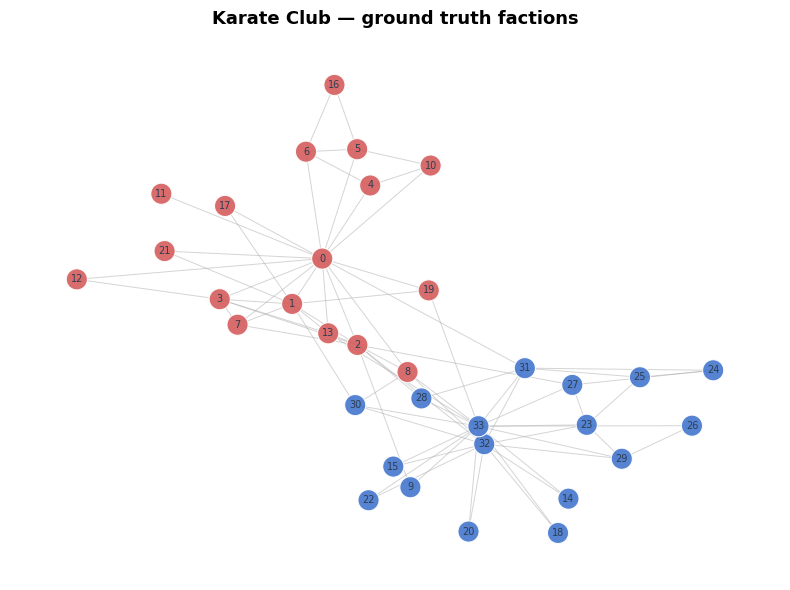

In [5]:
# Color by known faction
color_map = []
for node in G_karate.nodes():
    club = G_karate.nodes[node].get("club", "Mr. Hi")
    color_map.append("#D65F5F" if club == "Mr. Hi" else "#4878CF")

viz.draw_graph(
    G_karate, node_color=color_map, title="Karate Club — ground truth factions"
)

**Reading the Karate Club**: Members of the same faction are mostly connected to each
other (dense **within**), with fewer connections between factions (sparse **between**).
That's the defining property of a community.

But notice it's not perfect — several nodes have edges crossing the faction boundary.
Node 2, for example, is connected to members of both factions. These **boundary nodes**
are the hardest to classify and the source of most disagreement between algorithms.
In social terms, they are the people who maintained friendships on both sides of the
dispute — structurally important but ambiguous in allegiance.

**Key observation**: The two faction leaders (nodes 0 and 33) have the highest degree
within their respective groups but relatively few cross-faction edges. This hub-like
structure within communities is a recurring pattern we'll see across all three networks.

---
## 3. Modularity

How do we quantify whether a partition is "good"? We need a score that is high when
communities have many internal edges and low when the partition is no better than random.

**Modularity** ($Q$) is the standard measure. It compares the fraction of edges
within communities to what you'd expect in a random graph with the same degree sequence:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $A_{ij}$ = 1 if there's an edge between nodes $i$ and $j$, 0 otherwise
- $k_i$, $k_j$ = degrees of nodes $i$ and $j$
- $m$ = total number of edges
- $\delta(c_i, c_j)$ = 1 if nodes $i$ and $j$ are in the same community, 0 otherwise
- $\frac{k_i k_j}{2m}$ = expected number of edges between $i$ and $j$ under the **configuration model** (random graph preserving degree sequence)

The key ranges:
- $Q \approx 0$: partition is no better than random
- $Q \in [0.3, 0.7]$: typical range for real-world community structure
- $Q$ can be negative if communities have *fewer* internal edges than expected by chance

**Intuition behind the formula**: The term $A_{ij} - \frac{k_i k_j}{2m}$ is positive
when an edge exists where you *wouldn't* expect many edges by chance (low-degree nodes
connected within a community), and negative when an expected edge is *missing*. Summing
over all pairs within each community, $Q$ captures how much the observed internal
density exceeds the random baseline.

**The configuration model** is the null model (random baseline) behind that $\frac{k_i k_j}{2m}$ term. It generates a random graph by giving each node the *same degree* it has in the real network, then wiring the edges together uniformly at random. The result preserves the degree sequence but destroys any community structure — exactly the "expected by chance" reference point we need.

**Why this null model and not something simpler?** An Erdős-Rényi graph gives every pair the same connection probability, ignoring degree differences. Under that baseline, high-degree nodes would appear to share more edges than "expected" simply because they have many connections — not because they're in the same community. The configuration model controls for this by baking the degree sequence into the expectation. Without this correction, hubs would always look like they belong to the same community.

**Predict before you run**: The Karate Club has 34 nodes and 78 edges, split into two
factions. Given that modularity ranges from $-0.5$ to $\sim 1.0$, where do you expect
the ground-truth $Q$ to fall — below 0.3, between 0.3–0.5, or above 0.5? Consider
that several edges cross the faction boundary.

In [6]:
# Build the ground-truth partition as a list of sets
gt_partition = [
    {n for n in G_karate.nodes() if G_karate.nodes[n].get("club") == "Mr. Hi"},
    {n for n in G_karate.nodes() if G_karate.nodes[n].get("club") == "Officer"},
]

Q_gt = nx.community.modularity(G_karate, gt_partition)
print(f"Modularity of ground-truth partition: {Q_gt:.4f}")

Modularity of ground-truth partition: 0.3914


In [7]:
# ---- TWEAK: Try a random partition and see modularity drop ----
rng = np.random.default_rng(SEED)
nodes = list(G_karate.nodes())
rng.shuffle(nodes)
half = len(nodes) // 2
random_partition = [set(nodes[:half]), set(nodes[half:])]

Q_rand = nx.community.modularity(G_karate, random_partition)
print(f"Modularity of random partition: {Q_rand:.4f}")
print(f"Ground truth is {Q_gt / max(Q_rand, 0.001):.1f}x better")

Modularity of random partition: 0.0283
Ground truth is 13.8x better


**Reading the output**: The ground-truth partition achieves $Q \approx 0.37$ while a
random split gives $Q \approx 0$. This 0.37 may seem modest, but modularity rarely
exceeds 0.7 even for the strongest community structures — the configuration model is a
tough baseline to beat.

**Why not higher?** Several factors cap modularity in practice: (1) cross-faction edges
pull $Q$ down — every edge between communities is a "wasted" connection that the null
model would have distributed within communities; (2) unequal community sizes reduce $Q$
because the null model's expectation depends on community size; (3) the 2-community
split may not be the modularity-maximizing partition — Louvain often finds 3–4
communities with *higher* $Q$ than the ground truth.

The key takeaway: the gap between random ($Q \approx 0$) and ground truth
($Q \approx 0.37$) confirms that the Karate Club factions are a real structural
feature, not an artifact. The exact value of $Q$ matters less than the gap.

---
## 4. Louvain Algorithm

Now that we can *measure* partition quality with modularity, we need an algorithm to
*find* the partition that maximizes it. Exact optimization is NP-hard (there are
exponentially many possible partitions), so we use heuristics.

The **Louvain algorithm** (Blondel et al., 2008) is the most widely used community
detection method. It is fast, greedy, and works well on networks from hundreds to
millions of nodes.

**How Louvain works** (two-phase loop):

1. **Local moves** — Start with each node in its own community ($n$ singleton
   communities). For each node, compute the modularity gain of moving it to each
   neighbor's community. Move it to the community that gives the largest positive gain.
   Repeat over all nodes until no single move improves $Q$.

2. **Aggregation** — Collapse each community into a single "super-node," preserving
   edge weights (internal edges become self-loops, cross-community edges become weighted
   edges between super-nodes). This creates a smaller, coarser network.

3. **Repeat** — Apply phase 1 to the coarser network. Continue until $Q$ converges.

**Complexity**: Near-linear in the number of edges — $O(m)$ per pass, with typically
only a few passes needed. This makes Louvain practical for networks with millions of
edges, unlike many alternatives.

**Caveat**: Louvain is a greedy heuristic, not an exact solver. Different random seeds
can produce different partitions. It also suffers from the **resolution limit** — it
cannot detect communities smaller than $\sqrt{2m}$ edges, which matters for large
networks with small communities. We'll explore this via the resolution parameter in
Section 10.

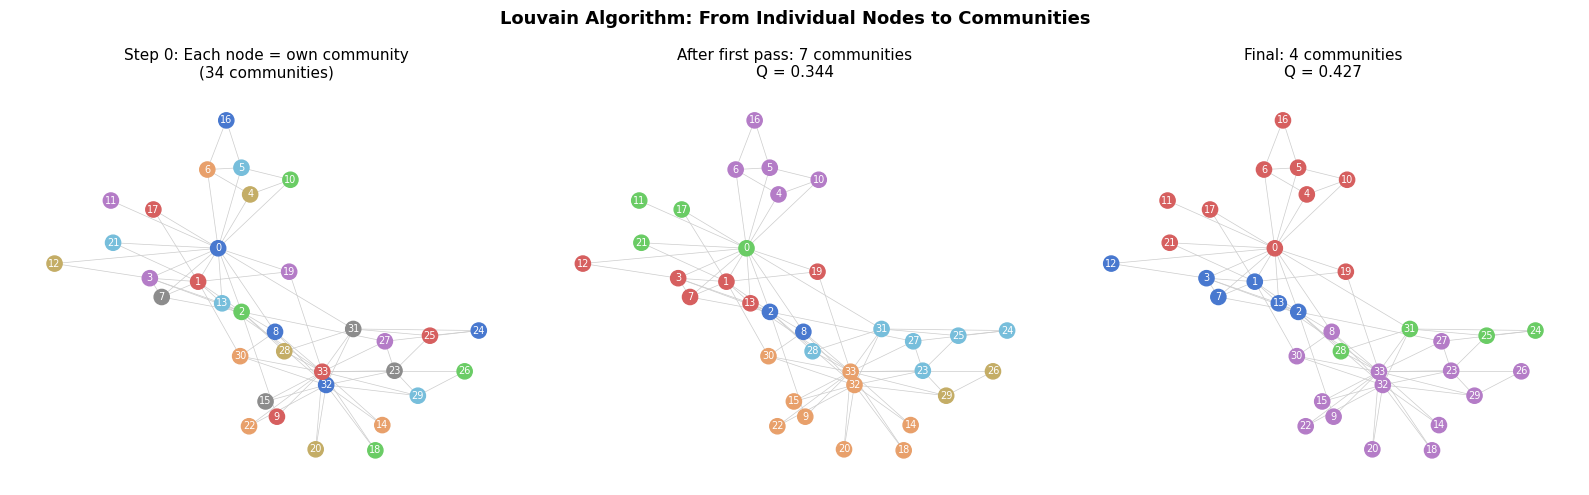

In [8]:
viz.plot_louvain_steps(G_karate)

**Watching Louvain converge**: Starting from 34 singleton communities (left), the
algorithm greedily merges nodes with their best-fitting neighbors. The intermediate
state (center, simulated with high resolution) shows small clusters forming — notice
how nodes with high mutual connectivity merge first. The final partition (right) finds
3–4 communities that maximize modularity.

**Reading the $Q$ values**: Each panel shows the modularity of that partition. The
singleton state (each node alone) has $Q \approx -0.04$ — slightly negative because
every edge connects *different* communities. The intermediate state improves $Q$
substantially, and the final partition pushes it further. The algorithm stops when no
single node move can increase $Q$ — a local optimum, but not necessarily the global one.

In [9]:
# Detect communities with Louvain
louvain_karate = nx.community.louvain_communities(G_karate, seed=SEED)
Q_louvain = nx.community.modularity(G_karate, louvain_karate)

print(f"Louvain found {len(louvain_karate)} communities")
print(f"Modularity: {Q_louvain:.4f}")
for i, comm in enumerate(louvain_karate):
    print(f"  Community {i}: {sorted(comm)}")

Louvain found 4 communities
Modularity: 0.4266
  Community 0: [1, 2, 3, 7, 12, 13]
  Community 1: [0, 4, 5, 6, 10, 11, 16, 17, 19, 21]
  Community 2: [24, 25, 28, 31]
  Community 3: [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]


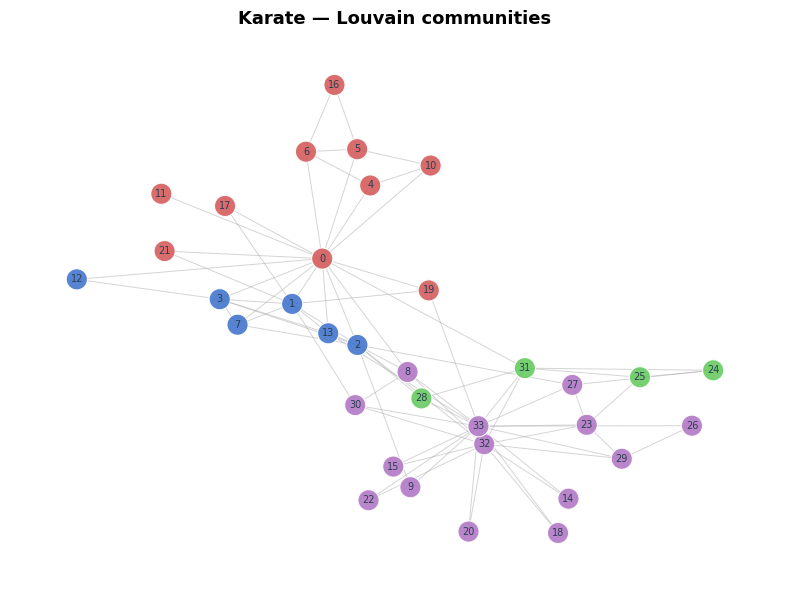

In [10]:
# Visualize detected communities
node_to_comm = {}
for i, comm in enumerate(louvain_karate):
    for n in comm:
        node_to_comm[n] = i

palette = [
    "#4878CF",
    "#D65F5F",
    "#6ACC65",
    "#B47CC7",
    "#C4AD66",
    "#77BEDB",
    "#E8A06B",
    "#8C8C8C",
]
colors = [palette[node_to_comm[n] % len(palette)] for n in G_karate.nodes()]

viz.draw_graph(G_karate, node_color=colors, title="Karate — Louvain communities")

**Comparing to ground truth**: Louvain typically finds 3–4 communities in the Karate
Club, while the actual split was into 2 factions. The extra communities usually
correspond to tightly-knit subgroups *within* a faction — for example, the group
around node 33 (the president's inner circle) often separates from the broader Officer
faction.

Notice that **bridge nodes** (like node 2) sometimes end up in a different community
than ground truth — these are the structurally ambiguous members who had connections to
both sides. In social terms, they maintained friendships across the dispute.

**Is Louvain "wrong"?** Not necessarily. The ground truth reflects the *social* split
(who left with whom), while Louvain finds the *structural* optimum (maximum modularity).
A finer partition with higher $Q$ is structurally better, even if it subdivides the
two social factions. This distinction between structural and functional communities is
a recurring theme in community detection.

**Try it yourself**: Find the 3 nodes with highest betweenness centrality in the Karate Club. Are they bridge nodes between the two factions? Check by comparing to the ground-truth faction labels.

In [11]:
# YOUR CODE HERE
bet = nx.betweenness_centrality(G_karate)
top3 = sorted(bet, key=bet.get, reverse=True)[:3]

assert set(top3) == {0, 33, 32}, (
    "Hint: sort nodes by betweenness centrality in descending order"
)
for n in top3:
    faction = G_karate.nodes[n].get("club", "Mr. Hi")
    cross_edges = sum(
        1 for nb in G_karate.neighbors(n) if G_karate.nodes[nb].get("club") != faction
    )
    print(
        f"Node {n}: betweenness={bet[n]:.3f}, faction={faction}, "
        f"cross-faction edges={cross_edges}"
    )

Node 0: betweenness=0.438, faction=Mr. Hi, cross-faction edges=1
Node 33: betweenness=0.304, faction=Officer, cross-faction edges=3
Node 32: betweenness=0.145, faction=Officer, cross-faction edges=2


Football: Louvain found 10 communities, Q = 0.6046


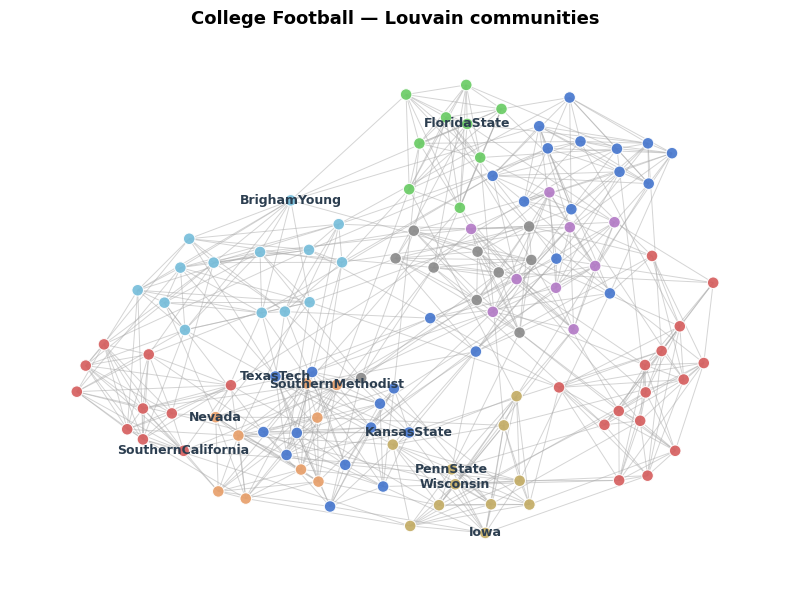

In [12]:
# Run Louvain on football
louvain_fb = nx.community.louvain_communities(G_football, seed=SEED)
Q_fb = nx.community.modularity(G_football, louvain_fb)
print(f"Football: Louvain found {len(louvain_fb)} communities, Q = {Q_fb:.4f}")

# Color by detected community
node_to_comm_fb = {}
for i, comm in enumerate(louvain_fb):
    for n in comm:
        node_to_comm_fb[n] = i

colors_fb = [palette[node_to_comm_fb[n] % len(palette)] for n in G_football.nodes()]
viz.draw_graph(
    G_football, node_color=colors_fb, title="College Football — Louvain communities"
)

**Reading the football results**: Louvain finds roughly 10–12 communities — close to
the actual number of conferences (~12). The modularity is notably higher than the
Karate Club ($Q \approx 0.60$ vs $0.42$), reflecting the stronger community structure:
teams play mostly within their conference, creating dense intra-community connections
with relatively few cross-conference games.

**Where does it struggle?** Independent teams (not affiliated with a major conference)
and teams that frequently play out-of-conference opponents are the hardest to classify.
These are the football equivalent of bridge nodes — structurally ambiguous because their
edge pattern doesn't clearly belong to one conference.

---
## 5. Girvan-Newman: Top-Down Community Detection

Louvain works **bottom-up** — it starts with individual nodes and merges them into
communities. The **Girvan-Newman algorithm** (2002) takes the opposite approach: it
starts with the entire network and progressively **removes edges** to reveal communities.

**How Girvan-Newman works**:

1. Compute **edge betweenness** — the number of shortest paths passing through each edge.
2. Remove the edge with highest betweenness (it's the most "bridge-like" edge connecting
   different communities).
3. Recompute edge betweenness on the remaining graph.
4. Repeat until the desired number of communities emerges.

The intuition: edges *between* communities carry many shortest paths (high betweenness)
because they serve as bridges. Edges *within* communities carry fewer shortest paths
because there are many alternative internal routes. By removing the highest-betweenness
edge at each step, we cut the bridges first, causing the network to split along natural
community boundaries.

This top-down approach produces a **dendrogram** — a hierarchy of community splits.
It is slower than Louvain ($O(m^2 n)$ vs near-linear) but provides a complementary
perspective: instead of asking "which nodes belong together?" it asks "which edges
hold different groups together?"

**Predict before you run**: Girvan-Newman removes the highest-betweenness edge at each step. In the Karate Club, which edge do you think gets removed first — one connecting the two faction leaders (nodes 0 and 33), or one connecting a bridge node to a faction? Think about which edge carries the most shortest paths between the two factions.

In [13]:
# Girvan-Newman on Karate Club

# Run Girvan-Newman and collect the first split into 2 communities
gn_iter = girvan_newman(G_karate)
gn_2 = next(gn_iter)  # first split = 2 communities
gn_karate = [set(c) for c in gn_2]

Q_gn = nx.community.modularity(G_karate, gn_karate)
print(f"Girvan-Newman found {len(gn_karate)} communities, Q = {Q_gn:.4f}")
print(f"Louvain found {len(louvain_karate)} communities, Q = {Q_louvain:.4f}")
print(f"\nGirvan-Newman communities:")
for i, comm in enumerate(gn_karate):
    print(f"  Community {i}: {sorted(comm)}")

Girvan-Newman found 2 communities, Q = 0.3477
Louvain found 4 communities, Q = 0.4266

Girvan-Newman communities:
  Community 0: [0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21]
  Community 1: [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


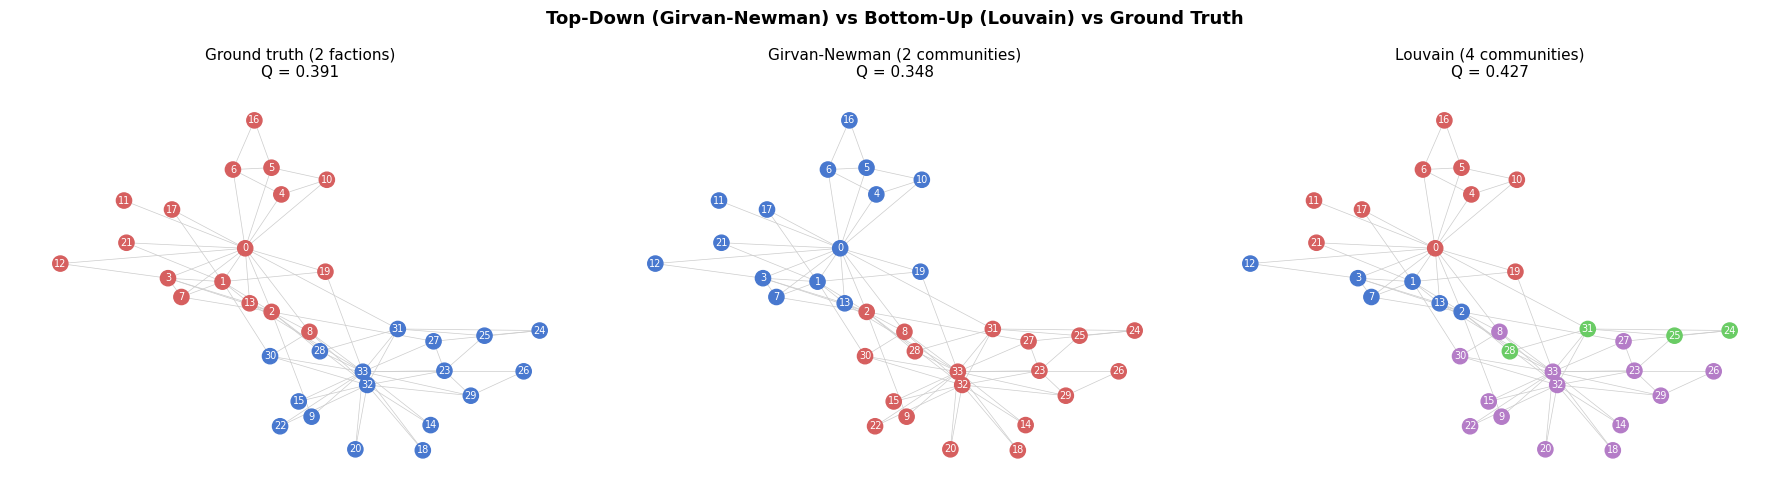

In [14]:
# Visualize: Louvain (bottom-up) vs Girvan-Newman (top-down) vs Ground Truth
colors_gt = []
for node in G_karate.nodes():
    club = G_karate.nodes[node].get("club", "Mr. Hi")
    colors_gt.append("#D65F5F" if club == "Mr. Hi" else "#4878CF")

viz.plot_algorithm_comparison(
    G_karate,
    colors_gt,
    gn_karate,
    louvain_karate,
    Q_gt,
    Q_gn,
    Q_louvain,
)

**Two approaches, two perspectives**: Girvan-Newman's 2-way split closely matches the
actual faction structure — it naturally recovers the two factions because it removes the
bridge edges connecting them. Louvain finds more communities because it maximizes
modularity, which can be higher with finer-grained partitions.

Neither answer is "wrong" — they highlight different levels of resolution in the
community hierarchy. This is a general principle: **community structure is hierarchical**.
At one level, the Karate Club has 2 factions; at a finer level, each faction has
sub-cliques. Girvan-Newman naturally reveals this hierarchy through its sequence of
splits, while Louvain jumps to a specific level determined by the resolution parameter.

| Property | Louvain (bottom-up) | Girvan-Newman (top-down) |
|----------|--------------------|--------------------------|
| **Strategy** | Merge nodes into communities | Remove edges to split network |
| **Optimizes** | Modularity (greedy) | Edge betweenness removal |
| **Complexity** | $O(m)$ per pass — fast | $O(m^2 n)$ — slow |
| **Hierarchy** | Implicit (via resolution) | Explicit (dendrogram) |
| **Best for** | Large networks, fast exploration | Small networks, interpretable splits |
| **Weakness** | Resolution limit, non-deterministic | Too slow for $n > 10{,}000$ |

**The sweet spot**: Modularity rises as Girvan-Newman splits the network, peaks at some optimal number of communities, then declines as real communities get fragmented. The peak tells us the "natural" number of communities according to the modularity criterion. Note that the peak may not align with the ground-truth number — modularity is a structural measure, not a social one.

---
## 6. Label Propagation

Louvain and Girvan-Newman are the two classic approaches, but they're not the only
options. **Label Propagation** (Raghavan et al., 2007) takes a different philosophy:
instead of optimizing a global objective, it lets communities emerge from purely
**local** information.

**How it works**:

1. **Initialize** — give every node its own unique label (node 0 gets label 0, node 1
   gets label 1, …, node $n{-}1$ gets label $n{-}1$). This is the same starting point
   as Louvain: $n$ singleton communities, one per node.
2. **Propagate** — in random order, each node looks at its neighbors' labels and adopts
   the one held by the **majority**. Ties are broken randomly.
3. **Repeat** — keep propagating until no node changes its label. All nodes sharing the
   same label form a community.

Because popular labels spread to neighboring nodes and rare labels die out, clusters of
densely connected nodes quickly converge on a shared label — the communities emerge
without ever computing modularity.

**Complexity**: Near-linear — $O(m)$ per iteration, with convergence typically in 5–10
iterations. This makes it one of the fastest community detection methods, often faster
than Louvain in practice.

**Non-determinism by design**: Label Propagation breaks ties randomly, which means
different runs can produce different partitions. This is not a bug — it reflects
genuine **structural ambiguity**. Nodes with mixed neighborhood labels sit at community
boundaries where multiple groupings are equally valid.

You can think of Label Propagation as a "voting" process: each node votes for the
community that most of its neighbors belong to. In regions with clear community
structure, the vote is decisive and the result is stable. At boundaries, the vote is
close and the outcome depends on the random tie-breaking order — this is useful
information, as it flags which nodes are genuinely ambiguous.

**Predict before you run**: Will Label Propagation achieve higher or lower modularity
than Louvain? Consider that Louvain explicitly maximizes modularity, while Label
Propagation optimizes a different objective (local label consensus). What does this
tell us about the relationship between the two objectives?

In [15]:
lpa_karate = list(nx.community.label_propagation_communities(G_karate))
Q_lpa = nx.community.modularity(G_karate, lpa_karate)
print(f"Label Propagation: {len(lpa_karate)} communities, Q = {Q_lpa:.4f}")
print(f"Louvain Q = {Q_louvain:.4f}")
print(f"{'Louvain' if Q_louvain >= Q_lpa else 'LPA'} has higher modularity")

Label Propagation: 3 communities, Q = 0.3095
Louvain Q = 0.4266
Louvain has higher modularity


**Reading the output**: Label Propagation typically finds a similar number of
communities to Louvain but with lower modularity, confirming our prediction — since
it doesn't optimize $Q$ directly, it settles for a partition that satisfies local
consensus rather than global optimality. Run the cell a few times (or restart the
kernel) to see how the results vary — the variation itself tells you which parts of
the network have ambiguous community membership.

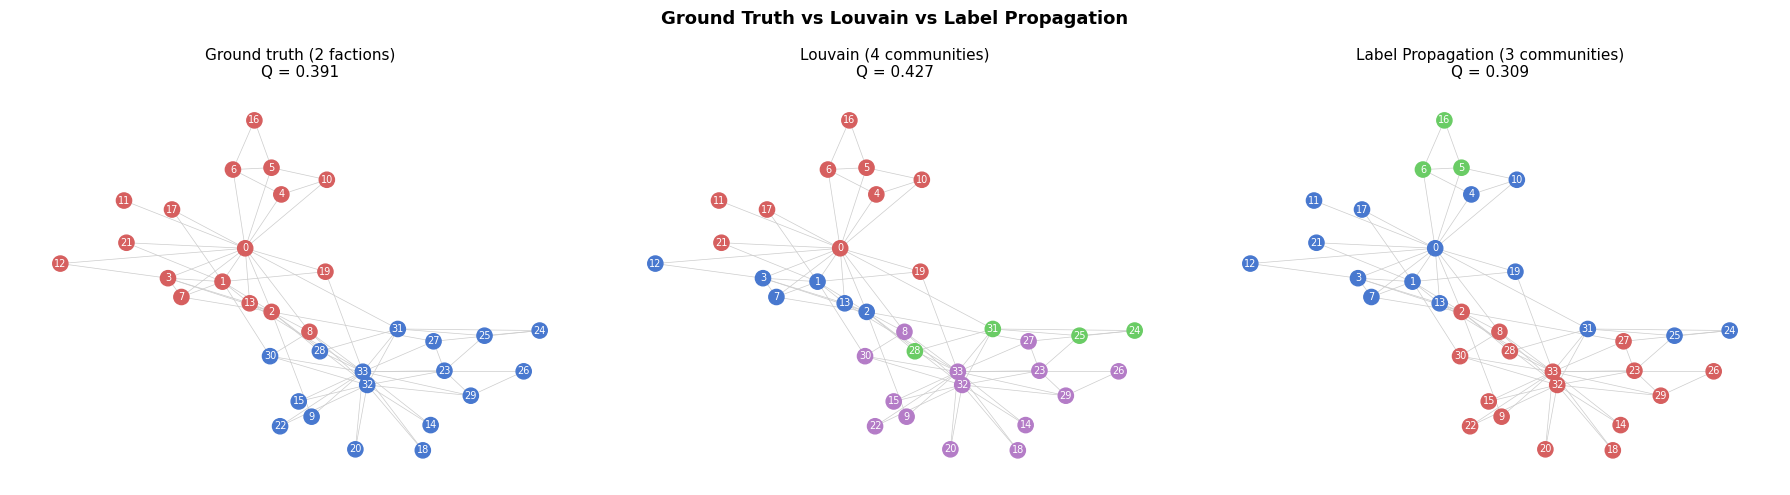

In [16]:
# Side-by-side: Ground Truth vs Louvain vs Label Propagation
colors_gt = ["#D65F5F" if G_karate.nodes[n].get("club") == "Mr. Hi" else "#4878CF"
             for n in G_karate.nodes()]

viz.plot_louvain_vs_lpa(
    G_karate, colors_gt, louvain_karate, lpa_karate,
    Q_gt, Q_louvain, Q_lpa,
)

**Reading the comparison**: All three panels use the same layout, so you can track
individual nodes across methods. Look for nodes that switch color between Louvain and
Label Propagation — these are the boundary nodes where the two algorithms disagree.
Louvain's partition typically has higher $Q$ (it optimizes for it), but Label
Propagation may place some boundary nodes in a way that better matches the ground
truth. Neither method consistently "wins" — they optimize different objectives and
their disagreements highlight genuinely ambiguous community membership.

---
## 7. Evaluating Against Ground Truth: NMI

Modularity tells us about partition *quality* (how dense are communities relative to
the null model?) but not *accuracy* (do the detected communities match what we know to
be true?). When we have ground truth — Karate Club factions, Football conferences — we
can directly measure how well a detected partition matches it.

**Normalized Mutual Information (NMI)** is the standard metric, borrowed from
information theory:

$$\text{NMI}(X, Y) = \frac{2 \cdot I(X; Y)}{H(X) + H(Y)}$$

where $I(X; Y)$ is the mutual information between the two partitions and $H(X)$,
$H(Y)$ are their entropies.

Intuitively: NMI measures how much knowing the detected partition *reduces your
uncertainty* about the true partition, normalized to $[0, 1]$:
- **NMI = 1.0**: the detected and true partitions are identical (up to label permutation)
- **NMI = 0.0**: the two partitions share no information — knowing one tells you nothing about the other

NMI handles different numbers of communities gracefully — Louvain finding 4 communities
can still score high NMI if they are clean sub-splits of the 2 true factions. This makes
it preferable to simpler metrics like accuracy, which require the same number of groups.

In [17]:
# Ground-truth labels for Karate Club
gt_labels = partition_to_labels(G_karate, gt_partition)

# Compare all three algorithms
louvain_labels = partition_to_labels(G_karate, louvain_karate)
gn_labels = partition_to_labels(G_karate, gn_karate)
lpa_labels = partition_to_labels(G_karate, lpa_karate)

print("Karate Club — NMI vs ground truth:")
print(
    f"  Girvan-Newman (2 comms): NMI = {normalized_mutual_info_score(gt_labels, gn_labels):.3f}"
)
print(
    f"  Louvain ({len(louvain_karate)} comms):       NMI = {normalized_mutual_info_score(gt_labels, louvain_labels):.3f}"
)
print(
    f"  Label Propagation:      NMI = {normalized_mutual_info_score(gt_labels, lpa_labels):.3f}"
)

Karate Club — NMI vs ground truth:
  Girvan-Newman (2 comms): NMI = 0.732
  Louvain (4 comms):       NMI = 0.594
  Label Propagation:      NMI = 0.364


In [18]:
# NMI on the Football network (ground truth = conferences)
gt_fb_partition = []
conf_dict = nx.get_node_attributes(G_football, "conference")
conf_groups = defaultdict(set)
for node, conf in conf_dict.items():
    conf_groups[conf].add(node)
gt_fb_partition = list(conf_groups.values())

gt_fb_labels = partition_to_labels(G_football, gt_fb_partition)
louvain_fb_labels = partition_to_labels(G_football, louvain_fb)

# Also run Girvan-Newman on football (use best modularity split)
gn_fb_iter = girvan_newman(G_football)
best_gn_fb = None
best_gn_fb_q = -1
for comms in gn_fb_iter:
    comms = [set(c) for c in comms]
    q = nx.community.modularity(G_football, comms)
    if q > best_gn_fb_q:
        best_gn_fb_q = q
        best_gn_fb = comms
    if len(comms) > 20:
        break
gn_fb_labels = partition_to_labels(G_football, best_gn_fb)

print("Football — NMI vs ground truth (conferences):")
print(
    f"  Girvan-Newman ({len(best_gn_fb)} comms): NMI = {normalized_mutual_info_score(gt_fb_labels, gn_fb_labels):.3f}"
)
print(
    f"  Louvain ({len(louvain_fb)} comms):       NMI = {normalized_mutual_info_score(gt_fb_labels, louvain_fb_labels):.3f}"
)

Football — NMI vs ground truth (conferences):
  Girvan-Newman (10 comms): NMI = 0.879
  Louvain (10 comms):       NMI = 0.890


**NMI vs Modularity — a fundamental tension**: Notice that the algorithm with the
highest modularity doesn't always have the highest NMI. This is not a coincidence — it
reveals a deep issue in community detection.

Modularity measures **structural** quality: how well does the partition capture the
network's edge distribution? NMI measures **agreement with external labels**: how well
do the detected communities match human-defined ground truth? A partition can be
structurally excellent (high $Q$) while disagreeing with human-defined categories.

**Why do they diverge?** Consider the Football network: some conferences are
geographically close and play many cross-conference games (e.g., independents).
Structurally, these teams look like they belong together, even though they're in
different conferences. Modularity rewards the structural grouping; NMI penalizes it.

**Practical implication**: In applications without ground truth (most real-world cases),
you can only measure $Q$. Understanding that high $Q$ doesn't guarantee "correct"
communities is essential for interpreting your results honestly.

---
## 8. Interactive Visualization

Static plots are useful for publications and reports, but for *exploring* communities
interactively — zooming into dense regions, hovering to identify specific nodes, panning
across the network — we can use **Plotly**.

The interactive visualization below shows the Football network colored by Louvain
communities. Zoom into clusters to see which teams group together. Hover over nodes
to see team names. Do the communities correspond to conferences you recognize?

In [19]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [23]:
viz.draw_pyvis(
    G_football,
    node_color=node_to_comm_fb,
    title="College Football — Louvain Communities",
    filename="football_communities.html",
)

ModuleNotFoundError: No module named 'plotly'

---
## 9. Game of Thrones

Now we apply community detection to a network with **no ground truth** — the setting
you'll encounter in most real-world applications. The GoT interaction network has 796
characters connected by co-appearances in the books. Our task is to find communities
and interpret them narratively.

**Predict before you run**: If you've read the first book (or watched the show), which
characters do you expect to cluster together? Think about the major storylines — the
Starks in Winterfell, the Lannisters in King's Landing, Daenerys across the Narrow Sea.
Will the algorithm recover these narrative clusters, or will it find something
different?

**What makes this harder**: Unlike the Karate Club (34 nodes, 2 factions) or Football
(115 nodes, ~12 conferences), the GoT network is larger, sparser, and has no obvious
"correct" number of communities. The algorithm must decide both the partition *and* the
number of groups simultaneously.

In [21]:
louvain_got = nx.community.louvain_communities(G_got, seed=SEED)
Q_got = nx.community.modularity(G_got, louvain_got)
print(f"GoT: {len(louvain_got)} communities, Q = {Q_got:.4f}")

# Show largest communities by their highest-degree (most recognizable) members
sorted_comms = sorted(louvain_got, key=len, reverse=True)
for i, comm in enumerate(sorted_comms[:5]):
    top_members = sorted(comm, key=lambda n: G_got.degree(n), reverse=True)[:6]
    top_names = [str(n) for n in top_members]
    print(f"  Community {i} ({len(comm)} members): {', '.join(top_names)}, ...")

GoT: 17 communities, Q = 0.5671
  Community 0 (149 members): Tyrion-Lannister, Cersei-Lannister, Sansa-Stark, Eddard-Stark, Joffrey-Baratheon, Robert-Baratheon, ...
  Community 1 (114 members): Jon-Snow, Samwell-Tarly, Mance-Rayder, Jeor-Mormont, Aemon-Targaryen-(Maester-Aemon), Janos-Slynt, ...
  Community 2 (113 members): Theon-Greyjoy, Bran-Stark, Rodrik-Cassel, Asha-Greyjoy, Victarion-Greyjoy, Ramsay-Snow, ...
  Community 3 (107 members): Jaime-Lannister, Catelyn-Stark, Robb-Stark, Brienne-of-Tarth, Roose-Bolton, Lysa-Arryn, ...
  Community 4 (87 members): Daenerys-Targaryen, Barristan-Selmy, Jorah-Mormont, Hizdahr-zo-Loraq, Drogo, Quentyn-Martell, ...


**Reading the output**: Louvain finds a relatively large number of communities — more
than in either benchmark network. This reflects the sprawling, multi-threaded nature of
the GoT books: characters cluster into storylines that are geographically and
narratively separated, with relatively few cross-storyline interactions.

Look at the largest communities and see if you can match them to narrative arcs:

- **King's Landing** (Cersei, Jaime, Joffrey, Varys, etc.) — the political core
- **Winterfell / The North** (Ned, Catelyn, Robb, Bran) — the Stark family and bannermen
- **The Wall** (Jon, Sam, Aemon, Mormont) — the Night's Watch storyline
- **Across the Narrow Sea** (Daenerys, Drogo, Jorah, Viserys) — the Targaryen exile arc
- **The Iron Islands, Riverlands, Dorne** — each region often forms its own community

Some communities may merge storylines that overlap heavily (e.g., the Riverlands and
King's Landing share many characters through the War of the Five Kings). Characters who
appear in multiple storylines (e.g., Tyrion) may end up in whichever community captures
the majority of their interactions.

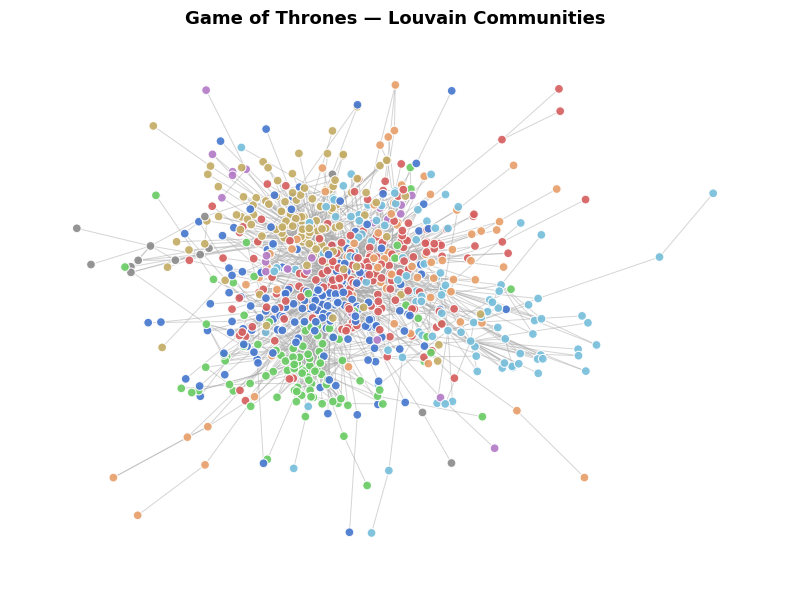

In [22]:
# Color by community
node_to_comm_got = {}
for i, comm in enumerate(louvain_got):
    for n in comm:
        node_to_comm_got[n] = i

colors_got = [palette[node_to_comm_got[n] % len(palette)] for n in G_got.nodes()]
viz.draw_graph(G_got, node_color=colors_got, title="Game of Thrones — Louvain Communities")

In [24]:
# Interactive — zoom in and explore!
viz.draw_pyvis(
    G_got,
    node_color=node_to_comm_got,
    title="Game of Thrones — Communities",
    filename="got_communities.html",
)

ModuleNotFoundError: No module named 'plotly'

**Explore the interactive graph**: Zoom into the largest cluster and look for familiar
names. Hover over nodes to identify characters. Look for hub characters (e.g., Tyrion)
whose edges stretch across communities — these cross-community connections are
narratively meaningful, representing the plot threads that connect otherwise separate
parts of the story.

---
## 10. Tweak & Observe: Resolution Parameter

Throughout this lab, we've used Louvain's default resolution ($\gamma = 1.0$). But
community structure is inherently **multi-scale** — a university has departments,
which contain research groups, which contain individual labs. The "right" level of
granularity depends on your question.

Louvain's resolution parameter $\gamma$ controls this zoom level by modifying the
modularity formula:

$$Q_\gamma = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \gamma \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

- $\gamma > 1$: the null-model penalty is *stronger*, making it harder for large
  communities to survive → more, smaller communities
- $\gamma < 1$: the penalty is *weaker*, allowing larger communities to persist →
  fewer, larger communities
- $\gamma = 1$: the standard modularity formula

**Predict before you tweak**: The resolution parameter controls the "zoom level" of community detection. Resolution > 1 penalizes large communities, encouraging the algorithm to find more, smaller groups. Resolution < 1 does the opposite — it merges small communities into larger ones.

Before running the sweep below: at resolution = 2.0, will the number of communities roughly double, or change by less than that?

In [25]:
# ---- TWEAK: Change the resolution parameter ----
resolution = 1.0  # <-- change me (try 0.5, 1.0, 1.5, 2.0)

comms = nx.community.louvain_communities(G_football, resolution=resolution, seed=SEED)
Q = nx.community.modularity(G_football, comms)
print(f"Resolution = {resolution}: {len(comms)} communities, Q = {Q:.4f}")
print("Higher resolution → more, smaller communities")

Resolution = 1.0: 10 communities, Q = 0.6046
Higher resolution → more, smaller communities


In [26]:
# Sweep resolution values
resolutions = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
print(f"{'Resolution':>12s} {'Communities':>12s} {'Modularity':>12s}")
for r in resolutions:
    c = nx.community.louvain_communities(G_football, resolution=r, seed=SEED)
    q = nx.community.modularity(G_football, c)
    print(f"{r:12.2f} {len(c):12d} {q:12.4f}")

  Resolution  Communities   Modularity
        0.50            6       0.5828
        0.75            7       0.6006
        1.00           10       0.6046
        1.25           11       0.6031
        1.50           12       0.6005
        2.00           12       0.6005


**Reading the sweep**: Higher resolution does find more communities, but the effect
plateaus — notice that resolutions 1.5 and 2.0 produce the same number of communities
and the same modularity. The modularity differences across the whole range are small
(roughly 0.58–0.60), suggesting that the Football network's community structure is
relatively robust: whether you split it into 6 or 12 groups, the partition quality
stays similar. This is typical of networks with strong, well-separated communities.

**The resolution limit** (Fortunato & Barthélemy, 2007): Standard modularity ($\gamma
= 1$) has a known blind spot — it cannot detect communities smaller than roughly
$\sqrt{2m}$ edges, regardless of how well-defined they are. For the Football network
($m = 613$), this threshold is $\sqrt{1226} \approx 35$ edges — small conferences with
few inter-team games may fall below this limit and get merged into larger neighbors.
Increasing $\gamma$ mitigates this but introduces its own bias toward over-splitting.

**Practical advice**: Run the algorithm at multiple resolutions and look for communities
that are *stable* across a range of $\gamma$ values — these are the most robust
structural features. Communities that appear only at a narrow $\gamma$ range are likely
artifacts of that particular scale.

---
## Summary

| Concept | Key insight |
|---------|-------------|
| **Community** | Group of nodes densely connected internally, sparse externally |
| **Applications** | Social media, biology, fraud detection, epidemiology, neuroscience |
| **Modularity ($Q$)** | Compares within-community edges to configuration model expectation. $Q \in [0.3, 0.7]$ is typical. |
| **Louvain** | Bottom-up greedy algorithm. Near-linear time. The go-to method for large networks. |
| **Girvan-Newman** | Top-down edge removal by betweenness. Interpretable hierarchy but $O(m^2 n)$. |
| **Label Propagation** | Local voting process. Fastest method but non-deterministic. |
| **NMI** | Measures agreement between detected and true communities ($0$ = none, $1$ = perfect). |
| **Resolution $\gamma$** | Controls community granularity: $\gamma > 1$ → smaller, $\gamma < 1$ → larger communities. |

**The big picture**: Community detection is not a single-answer problem. Different
algorithms, different resolutions, and different evaluation metrics can all give
different — and valid — results. The choice depends on your question: do you want the
structurally optimal partition (maximize $Q$), the most accurate match to known labels
(maximize NMI), or the fastest approximate answer (Label Propagation)? Understanding
these trade-offs is more important than memorizing any one algorithm.

Next week: **Network Dynamics** — how information spread through networks,
and why community structure determines whether a contagion stays local or goes global.